# Limpieza y exploración inicial del EUR/USD

En este notebook se carga el dataset original, se comprueba la calidad de los datos, se eliminan columnas que no aportan información y se analiza la evolución histórica del EUR/USD.

También se crea la variable objetivo:

- 1: el cierre de la siguiente jornada es mayor.
- 0: el cierre de la siguiente jornada es menor o igual.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Localizo la carpeta principal
ruta_actual = Path.cwd().resolve()

if ruta_actual.name == "notebooks":
    ruta_proyecto = ruta_actual.parent
else:
    ruta_proyecto = ruta_actual

# Defino las carpetas del proyecto
ruta_raw = ruta_proyecto / "data" / "raw"
ruta_processed = ruta_proyecto / "data" / "processed"
ruta_figures = ruta_proyecto / "outputs" / "figures"
ruta_tables = ruta_proyecto / "outputs" / "tables"

# Creo las carpetas si no existen
ruta_processed.mkdir(parents=True, exist_ok=True)
ruta_figures.mkdir(parents=True, exist_ok=True)
ruta_tables.mkdir(parents=True, exist_ok=True)

print("Proyecto:", ruta_proyecto)
print("Datos originales:", ruta_raw)
print("Datos procesados:", ruta_processed)

Proyecto: C:\TFM_EURUSD
Datos originales: C:\TFM_EURUSD\data\raw
Datos procesados: C:\TFM_EURUSD\data\processed


In [2]:
archivo_raw = ruta_raw / "eurusd_yfinance_diario.csv"

datos = pd.read_csv(
    archivo_raw,
    parse_dates=["Date"],
    index_col="Date"
)

# Ordeno las fechas

datos = datos.sort_index()

print("Dataset cargado correctamente.")
print("Filas:", len(datos))
print("Columnas:", len(datos.columns))

Dataset cargado correctamente.
Filas: 5845
Columnas: 6


In [3]:
print("Dimensiones:", datos.shape) # comprobacion rapida
print("Primera fecha:", datos.index.min())
print("Última fecha:", datos.index.max())
print("Orden cronológico:", datos.index.is_monotonic_increasing)

Dimensiones: (5845, 6)
Primera fecha: 2004-01-01 00:00:00
Última fecha: 2026-07-14 00:00:00
Orden cronológico: True


In [4]:
columnas_precios = ["Open", "High", "Low", "Close"]

columnas_faltantes = [
    columna
    for columna in columnas_precios
    if columna not in datos.columns
]

if columnas_faltantes:
    raise ValueError(
        f"Faltan columnas necesarias: {columnas_faltantes}"
    )
    
# Compruebo precios no válidos
filas_no_positivas = (
    datos[columnas_precios] <= 0
).any(axis=1).sum()

# El máximo debe ser el mayor precio de la jornada
high_incoherente = (
    datos["High"]
    < datos[["Open", "Close", "Low"]].max(axis=1)
).sum()

# El mínimo debe ser el menor precio de la jornada
low_incoherente = (
    datos["Low"]
    > datos[["Open", "Close", "High"]].min(axis=1)
).sum()

print("Filas con precios iguales o menores a cero:", filas_no_positivas)
print("Máximos incoherentes:", high_incoherente)
print("Mínimos incoherentes:", low_incoherente)

Filas con precios iguales o menores a cero: 0
Máximos incoherentes: 54
Mínimos incoherentes: 73


In [5]:
# Identifico las filas con precios incoherentes
mas_alto = datos[["Open", "Close", "Low"]].max(axis=1)
mas_bajo = datos[["Open", "Close", "High"]].min(axis=1)

mascara_high = datos["High"] < mas_alto
mascara_low = datos["Low"] > mas_bajo

anomalias = datos[mascara_high | mascara_low].copy()

# Calculo la diferencia para saber si es pequeña o importante
anomalias["diferencia_high"] = mas_alto - datos["High"]
anomalias["diferencia_low"] = datos["Low"] - mas_bajo

print("Filas anómalas distintas:", len(anomalias))
display(anomalias.head(20))

Filas anómalas distintas: 127


,Adj Close,Close,High,Low,Open,Volume,diferencia_high,diferencia_low
Date,,,,,,,,
2004-04-21,1.181000,1.181000,1.191199,1.182103,1.184806,0,-0.006393,0.001103
2004-11-08,1.290806,1.290806,1.298802,1.291005,1.296395,0,-0.002408,0.000200
2005-06-14,1.202603,1.202603,1.214993,1.202805,1.211695,0,-0.003298,0.000202
2005-10-05,1.201201,1.201201,1.201100,1.191696,1.191796,0,0.000101,-0.000099
2005-11-30,1.180498,1.180498,1.180206,1.175903,1.176803,0,0.000293,-0.000899
2006-08-08,1.276699,1.276699,1.288494,1.277906,1.281903,0,-0.006590,0.001207
2007-03-15,1.328304,1.328304,1.328198,1.319801,1.323399,0,0.000106,-0.003598
2007-08-21,1.345497,1.345497,1.352009,1.345696,1.347400,0,-0.004609,0.000199
2009-02-23,1.267813,1.267813,1.298499,1.269487,1.279100,0,-0.019399,0.001674


In [6]:
# Creo una copia para no modificar los datos raw
datos_corregidos = datos.copy()

# Corrijo los máximos y mínimos incoherentes
datos_corregidos["High"] = datos[
    ["Open", "High", "Low", "Close"]
].max(axis=1)

datos_corregidos["Low"] = datos[
    ["Open", "High", "Low", "Close"]
].min(axis=1)

# Compruebo nuevamente la coherencia
high_incoherente_despues = (
    datos_corregidos["High"]
    < datos_corregidos[["Open", "Close", "Low"]].max(axis=1)
).sum()

low_incoherente_despues = (
    datos_corregidos["Low"]
    > datos_corregidos[["Open", "Close", "High"]].min(axis=1)
).sum()

print("Filas corregidas:", len(anomalias))
print("Máximos incoherentes después:", high_incoherente_despues)
print("Mínimos incoherentes después:", low_incoherente_despues)

Filas corregidas: 127
Máximos incoherentes después: 0
Mínimos incoherentes después: 0


In [7]:
# Continúo trabajando con los datos corregidos
datos = datos_corregidos

In [8]:
if "Volume" in datos.columns:
    volumen_cero = datos["Volume"].fillna(0).eq(0).sum()
    porcentaje_cero = volumen_cero / len(datos) * 100

    print("Registros con volumen igual a cero:", volumen_cero)
    print("Porcentaje:", round(porcentaje_cero, 2), "%")

if "Adj Close" in datos.columns:
    diferencia_adj_close = (
        datos["Adj Close"] - datos["Close"]
    ).abs()

    print(
        "Diferencia máxima entre Adj Close y Close:",
        diferencia_adj_close.max()
    )

# el volumen de Yahoo normalmente aparece completamente en cero, también es probable que Adj Close sea exactamente igual a Close

# esto lo hago para descartar estas dos columnas (no me aportan ninguna informacion adicional)

Registros con volumen igual a cero: 5845
Porcentaje: 100.0 %
Diferencia máxima entre Adj Close y Close: 0.0


In [9]:
# Trabajo con una copia (es una copia de los datos ya limpios del paso anterior - por seguridad)
datos_limpios = datos.copy()

# Elimino fechas duplicadas si existieran
datos_limpios = datos_limpios[
    ~datos_limpios.index.duplicated(keep="first")
]

# Elimino filas sin precios esenciales
datos_limpios = datos_limpios.dropna(
    subset=columnas_precios
)

columnas_eliminadas = []

# Elimino Volume si todos sus valores son cero
if (
    "Volume" in datos_limpios.columns
    and datos_limpios["Volume"].fillna(0).eq(0).all()
):
    datos_limpios = datos_limpios.drop(columns="Volume")
    columnas_eliminadas.append("Volume")

# Elimino Adj Close si es igual a Close
if "Adj Close" in datos_limpios.columns:
    diferencia_maxima = (
        datos_limpios["Adj Close"]
        - datos_limpios["Close"]
    ).abs().max()

    if diferencia_maxima < 1e-12:
        datos_limpios = datos_limpios.drop(
            columns="Adj Close"
        )
        columnas_eliminadas.append("Adj Close")
        
print("Columnas eliminadas:", columnas_eliminadas)
print("Columnas conservadas:", datos_limpios.columns.tolist())
print("Número de filas:", len(datos_limpios))

Columnas eliminadas: ['Volume', 'Adj Close']
Columnas conservadas: ['Close', 'High', 'Low', 'Open']
Número de filas: 5845


In [10]:
orden_columnas = ["Open", "Low", "High", "Close"]

datos_limpios = datos_limpios[orden_columnas]

display(datos_limpios.head()) # solo para entender mejor el dataset

,Open,Low,High,Close
Date,,,,
2004-01-01,1.259002,1.247396,1.260796,1.258194
2004-01-02,1.258194,1.252693,1.262802,1.258194
2004-01-05,1.263903,1.263695,1.269406,1.268698
2004-01-06,1.268907,1.267202,1.280803,1.272103
2004-01-07,1.272394,1.262499,1.273999,1.264095


In [11]:
datos_limpios["Retorno_diario"] = ( #con el retorno diario indico cuanto cambió el cierre frente a la jornada anterior
    datos_limpios["Close"].pct_change()
)

display(
    datos_limpios[
        ["Close", "Retorno_diario"]
    ].head()
)

,Close,Retorno_diario
Date,,
2004-01-01,1.258194,NaN
2004-01-02,1.258194,0.000000
2004-01-05,1.268698,0.008348
2004-01-06,1.272103,0.002684
2004-01-07,1.264095,-0.006295


In [12]:
# En esta aprte voy a crear la variable objetivo, para cada jornada voy a comparar el cierre de la siguiente jornada vs la actual

# Obtengo el cierre de la siguiente jornada
cierre_siguiente = datos_limpios["Close"].shift(-1)

# Creo la variable objetivo
objetivo = (
    cierre_siguiente > datos_limpios["Close"]
).astype("Int64")

# La ultima jornada todavía no tiene resultado conocido por eso no lo quiero clasificar como 0 ese vacío
objetivo[cierre_siguiente.isna()] = pd.NA

datos_limpios["Objetivo"] = objetivo

display(
    datos_limpios[
        ["Close", "Retorno_diario", "Objetivo"]
    ].tail(10)
)

,Close,Retorno_diario,Objetivo
Date,,,
2026-07-01,1.141331,-0.000765,0
2026-07-02,1.137799,-0.003095,1
2026-07-03,1.142270,0.003929,1
2026-07-06,1.143772,0.001315,1
2026-07-07,1.144178,0.000355,0
2026-07-08,1.140381,-0.003318,1
2026-07-09,1.142204,0.001599,1
2026-07-10,1.143341,0.000995,0
2026-07-13,1.140446,-0.002532,0


In [13]:
comprobacion_objetivo = pd.DataFrame({ # comprobacion de la variable objetivo
    "cierre_actual": datos_limpios["Close"],
    "cierre_siguiente": cierre_siguiente,
    "objetivo": datos_limpios["Objetivo"]
})

# Muestro 10 filas aleatorias distintas cada vez
display(
    comprobacion_objetivo
    .dropna()
    .sample(n=10)
)

,cierre_actual,cierre_siguiente,objetivo
Date,,,
2024-05-30,1.080182,1.083541,1
2005-02-04,1.285793,1.276406,0
2004-06-25,1.220301,1.218695,0
2010-07-19,1.293946,1.289308,0
2024-07-31,1.081607,1.082392,1
2012-01-13,1.282051,1.264702,0
2013-12-27,1.369619,1.375024,1
2025-12-02,1.160766,1.162791,1
2009-06-24,1.394097,1.398562,1


In [14]:
balance_clases = ( # analizo el equilibrio entre subidas y bajadas
    datos_limpios["Objetivo"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

balance_clases.index = balance_clases.index.map({
    0: "Baja",
    1: "Sube"
})

balance_clases = balance_clases.to_frame(
    name="jornadas"
)

balance_clases["porcentaje"] = (
    balance_clases["jornadas"]
    / balance_clases["jornadas"].sum()
    * 100
).round(2)

display(balance_clases)

,jornadas,porcentaje
Objetivo,,
Baja,2950,50.48
Sube,2894,49.52


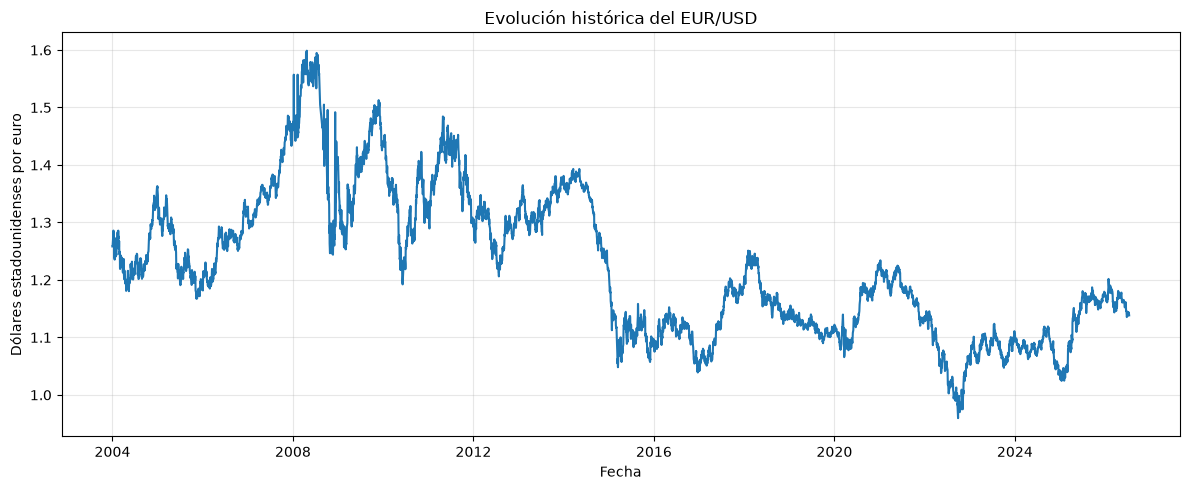

Figura guardada en:
C:\TFM_EURUSD\outputs\figures\01_evolucion_historica_eurusd.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 5)) # evolucion del EUR/USD

ax.plot(
    datos_limpios.index,
    datos_limpios["Close"]
)

ax.set_title("Evolución histórica del EUR/USD")
ax.set_xlabel("Fecha")
ax.set_ylabel("Dólares estadounidenses por euro")
ax.grid(alpha=0.3)

fig.tight_layout()

archivo_figura = (
    ruta_figures / "01_evolucion_historica_eurusd.png"
)

fig.savefig(
    archivo_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada en:")
print(archivo_figura)

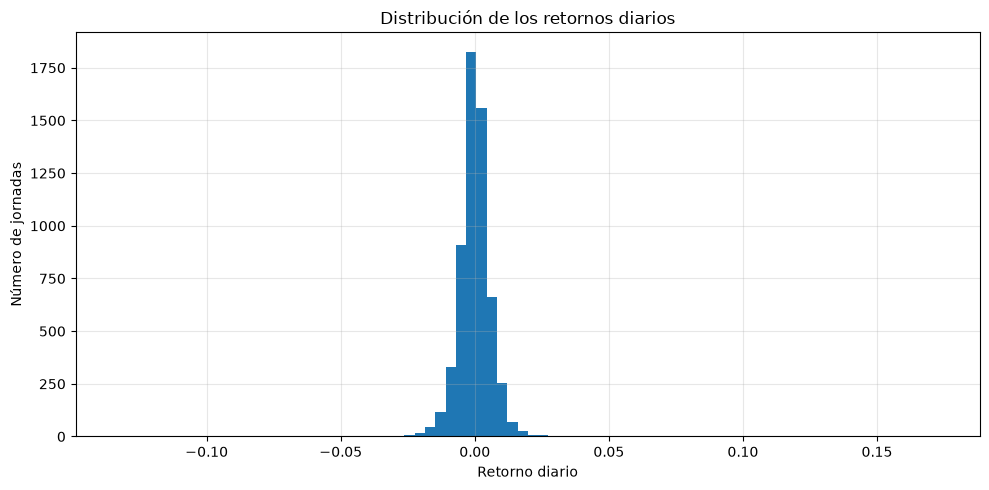

Figura guardada en:
C:\TFM_EURUSD\outputs\figures\02_distribucion_retornos.png


In [17]:
retornos_validos = ( # grafica de retornos diarios
    datos_limpios["Retorno_diario"].dropna()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    retornos_validos,
    bins=80
)

ax.set_title("Distribución de los retornos diarios")
ax.set_xlabel("Retorno diario")
ax.set_ylabel("Número de jornadas")
ax.grid(alpha=0.3)

fig.tight_layout()

archivo_figura = (
    ruta_figures / "02_distribucion_retornos.png"
)

fig.savefig(
    archivo_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada en:")
print(archivo_figura)

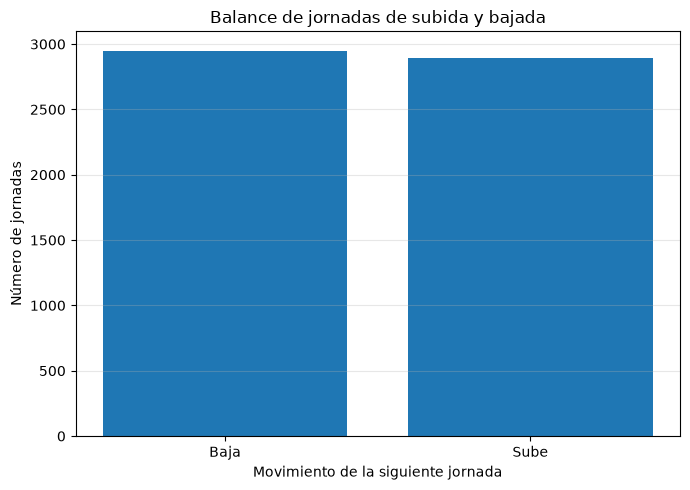

Figura guardada en:
C:\TFM_EURUSD\outputs\figures\03_balance_clases.png


In [18]:
fig, ax = plt.subplots(figsize=(7, 5)) # balance de clases

ax.bar(
    balance_clases.index,
    balance_clases["jornadas"]
)

ax.set_title("Balance de jornadas de subida y bajada")
ax.set_xlabel("Movimiento de la siguiente jornada")
ax.set_ylabel("Número de jornadas")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

archivo_figura = (
    ruta_figures / "03_balance_clases.png"
)

fig.savefig(
    archivo_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada en:")
print(archivo_figura)

In [19]:
datos_anuales = datos_limpios.copy() # resumen anual de las jornadas

datos_anuales["Anio"] = datos_anuales.index.year

datos_anuales["Sube"] = (
    datos_anuales["Objetivo"].eq(1)
    .fillna(False)
    .astype(int)
)

datos_anuales["Baja"] = (
    datos_anuales["Objetivo"].eq(0)
    .fillna(False)
    .astype(int)
)

resumen_anual = datos_anuales.groupby("Anio").agg(
    precio_inicio=("Close", "first"),
    precio_fin=("Close", "last"),
    precio_minimo=("Close", "min"),
    precio_maximo=("Close", "max"),
    retorno_medio=("Retorno_diario", "mean"),
    volatilidad=("Retorno_diario", "std"),
    jornadas_subida=("Sube", "sum"),
    jornadas_bajada=("Baja", "sum")
)

display(resumen_anual)

,precio_inicio,precio_fin,precio_minimo,precio_maximo,retorno_medio,volatilidad,jornadas_subida,jornadas_bajada
Anio,,,,,,,,
2004,1.258194,1.356502,1.180401,1.362806,0.000313,0.006850,139,122
2005,1.347001,1.184105,1.167556,1.347291,-0.000509,0.005578,117,142
2006,1.181698,1.319801,1.181698,1.339405,0.000429,0.004859,130,130
2007,1.321895,1.460110,1.289507,1.485796,0.000399,0.003919,140,118
2008,1.462010,1.397995,1.243905,1.598798,0.000053,0.021697,117,126
2009,1.399894,1.432706,1.253180,1.512791,0.000124,0.007770,132,129
2010,1.438994,1.330123,1.192293,1.452391,-0.000257,0.007443,131,130
2011,1.335791,1.295605,1.289507,1.484406,-0.000072,0.007672,140,120
2012,1.296008,1.322769,1.206185,1.347800,0.000095,0.005506,121,139


In [20]:
archivo_resumen_anual = (
    ruta_tables / "resumen_anual_eurusd.csv"
)

resumen_anual.to_csv(
    archivo_resumen_anual,
    encoding="utf-8"
)

print("Resumen anual guardado en:")
print(archivo_resumen_anual)

Resumen anual guardado en:
C:\TFM_EURUSD\outputs\tables\resumen_anual_eurusd.csv


In [ ]:
archivo_limpio = ( # guardo el dataset limpio
    ruta_processed / "eurusd_yahoo_limpio.csv"
)

datos_limpios.to_csv(
    archivo_limpio,
    index=True,
    encoding="utf-8"
)

print("Dataset limpio guardado en:")
print(archivo_limpio)

print("\nDimensiones finales:")
print(datos_limpios.shape)

print("\nColumnas finales:")
print(datos_limpios.columns.tolist())

Dataset limpio guardado en:
C:\TFM_EURUSD\data\processed\eurusd_limpio.csv

Dimensiones finales:
(5845, 6)

Columnas finales:
['Open', 'Low', 'High', 'Close', 'Retorno_diario', 'Objetivo']


In [22]:
datos_verificacion = pd.read_csv( # para asegurarme que el archivo final se guardó bien
    archivo_limpio,
    parse_dates=["Date"],
    index_col="Date"
)

datos_verificacion["Objetivo"] = (
    datos_verificacion["Objetivo"].astype("Int64")
)

if len(datos_verificacion) != len(datos_limpios):
    raise ValueError(
        "El número de filas cambió al guardar el archivo."
    )

if list(datos_verificacion.columns) != list(
    datos_limpios.columns
):
    raise ValueError(
        "Las columnas cambiaron al guardar el archivo."
    )

print("El dataset limpio se guardó correctamente.")
print("Filas verificadas:", len(datos_verificacion))

display(datos_verificacion.tail())

El dataset limpio se guardó correctamente.
Filas verificadas: 5845


,Open,Low,High,Close,Retorno_diario,Objetivo
Date,,,,,,
2026-07-08,1.140095,1.139186,1.143249,1.140381,-0.003318,1
2026-07-09,1.142191,1.142126,1.145082,1.142204,0.001599,1
2026-07-10,1.143380,1.141839,1.146263,1.143341,0.000995,0
2026-07-13,1.140368,1.138680,1.144571,1.140446,-0.002532,0
2026-07-14,1.138369,1.137877,1.146132,1.138433,-0.001765,<NA>
